<a href="https://colab.research.google.com/github/yasirusman85/Training-1/blob/main/Copy_of_Training1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
preetpalsingh25_alzheimers_dataset_4_class_of_images_path = kagglehub.dataset_download('preetpalsingh25/alzheimers-dataset-4-class-of-images')

print('Data source import complete.')


100%|██████████| 56.4M/56.4M [00:00<00:00, 255MB/s]

Extracting files...


Data source import complete.


In [3]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [4]:
import os

# Get the base path for the dataset
dataset_base_path = preetpalsingh25_alzheimers_dataset_4_class_of_images_path

print(f"Contents of the dataset base path: {dataset_base_path}")
for item in os.listdir(dataset_base_path):
    print(f"- {item}")


Contents of the dataset base path: /root/.cache/kagglehub/datasets/preetpalsingh25/alzheimers-dataset-4-class-of-images/versions/1
- Alzheimer_s Dataset


The output above shows the top-level directories within your dataset. Typically, in image datasets, you'll find 'train', 'test', and 'validation' folders. The actual image categories are usually within these folders. Let's look inside the 'train' folder to see the categories.

In [5]:
import os

# Adjust the path to include the nested 'Alzheimer_s Dataset' folder
actual_data_path = os.path.join(dataset_base_path, 'Alzheimer_s Dataset')
train_path = os.path.join(actual_data_path, 'train')

if os.path.exists(train_path) and os.path.isdir(train_path):
    print(f"Categories found in: {train_path}")
    categories = sorted([d for d in os.listdir(train_path) if os.path.isdir(os.path.join(train_path, d))])
    for cat in categories:
        cat_dir = os.path.join(train_path, cat)
        file_count = len(os.listdir(cat_dir))
        print(f"- {cat}: {file_count} images")
else:
    print(f"Could not find 'train' folder. Contents of {actual_data_path}:")
    if os.path.exists(actual_data_path):
        print(os.listdir(actual_data_path))
    else:
        print("Path does not exist.")

Categories found in: /root/.cache/kagglehub/datasets/preetpalsingh25/alzheimers-dataset-4-class-of-images/versions/1/Alzheimer_s Dataset/train
- MildDemented: 896 images
- ModerateDemented: 64 images
- NonDemented: 3200 images
- VeryMildDemented: 2240 images


### Step 1: Data Preparation & Augmentation
We will create a balanced dataset directory with 1,000 images per class. For classes with fewer than 1,000 images, we will apply random rotations, flips, and zooms to generate the necessary samples.

In [6]:
import shutil
import random
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array, array_to_img

# Create a working directory for our balanced dataset
base_dir = './balanced_dataset'
if os.path.exists(base_dir): shutil.rmtree(base_dir)
os.makedirs(base_dir)

target_count = 1000
datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

for cat in categories:
    cat_src = os.path.join(train_path, cat)
    cat_dest = os.path.join(base_dir, cat)
    os.makedirs(cat_dest)

    files = [f for f in os.listdir(cat_src) if os.path.isfile(os.path.join(cat_src, f))]
    current_count = len(files)

    print(f"Processing {cat}: {current_count} source images...")

    # 1. Copy existing images (up to target_count)
    sampled_files = random.sample(files, min(current_count, target_count))
    for f in sampled_files:
        shutil.copy(os.path.join(cat_src, f), os.path.join(cat_dest, f))

    # 2. Augment if we are below 1000
    if current_count < target_count:
        needed = target_count - current_count
        print(f"  Augmenting {needed} more images for {cat}...")
        for i in range(needed):
            # Pick a random original image to augment
            img_path = os.path.join(cat_src, random.choice(files))
            img = img_to_array(load_img(img_path))
            img = img.reshape((1,) + img.shape)

            # Generate one augmented image
            for batch in datagen.flow(img, batch_size=1, save_to_dir=cat_dest, save_prefix='aug', save_format='jpg'):
                break

print("Balanced dataset created at ./balanced_dataset")

Processing MildDemented: 896 source images...
  Augmenting 104 more images for MildDemented...
Processing ModerateDemented: 64 source images...
  Augmenting 936 more images for ModerateDemented...
Processing NonDemented: 3200 source images...
Processing VeryMildDemented: 2240 source images...
Balanced dataset created at ./balanced_dataset


In [7]:
# Verify the new counts
for cat in os.listdir(base_dir):
    path = os.path.join(base_dir, cat)
    print(f"{cat}: {len(os.listdir(path))} images")

ModerateDemented: 961 images
MildDemented: 1000 images
VeryMildDemented: 1000 images
NonDemented: 1000 images


### Step 2: Data Splitting and Data Loaders
We will now use `image_dataset_from_directory` to load our balanced images, split them into training (80%) and validation (20%) sets, and resize them to 224x224, which is the standard input size for DenseNet.

In [8]:
import tensorflow as tf
from tensorflow.keras.utils import image_dataset_from_directory

img_size = (224, 224)
batch_size = 32

# Load training data
train_ds = image_dataset_from_directory(
    base_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=img_size,
    batch_size=batch_size
)

# Load validation data
val_ds = image_dataset_from_directory(
    base_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=img_size,
    batch_size=batch_size
)

class_names = train_ds.class_names
print(f"Class names: {class_names}")

# Configure for performance
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

Found 3961 files belonging to 4 classes.
Using 3169 files for training.
Found 3961 files belonging to 4 classes.
Using 792 files for validation.
Class names: ['MildDemented', 'ModerateDemented', 'NonDemented', 'VeryMildDemented']


### Step 3: Build the DenseNet Model
We initialize the DenseNet121 model with pre-trained ImageNet weights. We freeze the base layers to retain the learned features and add a custom top layer for our 4-class Alzheimer's prediction.

In [9]:
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras import layers, models

# Base model with pre-trained weights
base_model = DenseNet121(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze the base model
base_model.trainable = False

# Create the full model
model = models.Sequential([
    layers.Rescaling(1./255, input_shape=(224, 224, 3)),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(len(class_names), activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,300,932 (27.85 MB)

 Trainable params: 263,428 (1.00 MB)

 Non-trainable params: 7,037,504 (26.85 MB)

### Step 4: Model Training
We will train the model for 10 epochs. This should give us a good indication of the model's performance on the balanced Alzheimer's dataset.

In [10]:
import tensorflow as tf

# Verify GPU availability
device_name = tf.test.gpu_device_name()
if device_name != '/device:GPU:0':
  print('GPU device not found')
else:
  print('Found GPU at: {}'.format(device_name))

# Training will automatically use the GPU if available
epochs = 10

with tf.device('/device:GPU:0'):
    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=epochs
    )

Found GPU at: /device:GPU:0
Epoch 1/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 73s 440ms/step - accuracy: 0.4456 - loss: 1.2724 - val_accuracy: 0.5619 - val_loss: 0.9721
Epoch 2/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 97ms/step - accuracy: 0.5377 - loss: 0.9841 - val_accuracy: 0.6098 - val_loss: 0.8782
Epoch 3/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 96ms/step - accuracy: 0.5737 - loss: 0.9062 - val_accuracy: 0.6174 - val_loss: 0.8332
Epoch 4/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 88ms/step - accuracy: 0.5895 - loss: 0.8645 - val_accuracy: 0.5985 - val_loss: 0.8361
Epoch 5/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 87ms/step - accuracy: 0.5977 - loss: 0.8447 - val_accuracy: 0.6326 - val_loss: 0.8085
Epoch 6/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 89ms/step - accuracy: 0.6109 - loss: 0.8199 - val_accuracy: 0.6124 - val_loss: 0.8350
Epoch 7/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 90ms/step - accuracy: 0.6062 - loss: 0.8333 - val_accuracy: 0.6641 - val_loss: 0.7784
Epoch 8/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 89ms/step - accuracy: 

### Step 5: Visualize Results
After training, it's helpful to plot the training and validation accuracy/loss to check for overfitting.

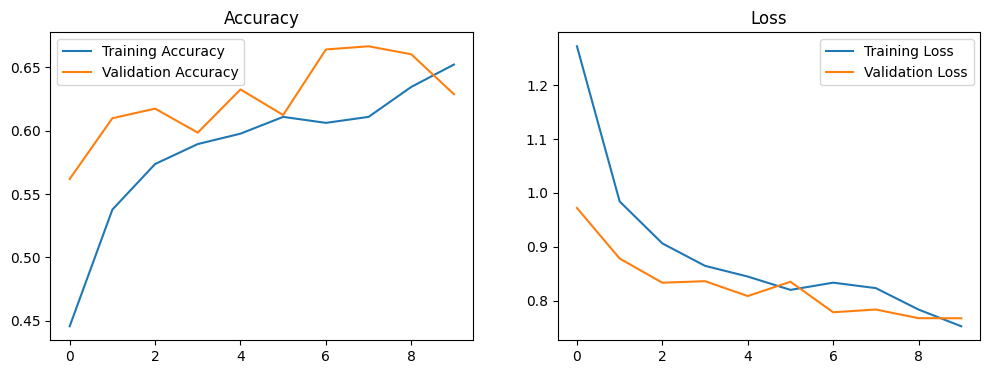

In [11]:
import matplotlib.pyplot as plt

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.legend()
plt.title('Accuracy')

plt.subplot(1, 2, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.legend()
plt.title('Loss')
plt.show()

In [12]:
final_train_accuracy = history.history['accuracy'][-1]
final_val_accuracy = history.history['val_accuracy'][-1]
final_train_loss = history.history['loss'][-1]
final_val_loss = history.history['val_loss'][-1]

print(f"Final Training Accuracy:   {final_train_accuracy:.4f}")
print(f"Final Validation Accuracy: {final_val_accuracy:.4f}")
print(f"Final Training Loss:       {final_train_loss:.4f}")
print(f"Final Validation Loss:     {final_val_loss:.4f}")

Final Training Accuracy:   0.6523
Final Validation Accuracy: 0.6288
Final Training Loss:       0.7523
Final Validation Loss:     0.7672
